# 24. 분산분해: 시장 축은 얼마나 큰 몫인가

## Overview

23번에서 **쓸 만한 처치를 못 찾았습니다.** 명절은 예상 가능해서 식별력이 약하고,
국지 기상은 지점 매칭이 5개 중 2개만 정확하며, 미거래 급증은 97%가 구조적이고
78%가 전국 공통이었습니다.

**처치를 계속 찾기 전에 물어야 할 게 있습니다: 이 축이 애초에 큰가?**

22번은 "시장 간 가격이 1.10~1.59배 다르다"까지만 말했습니다. 그건 **얼마나
다른가**이지 **전체 변동에서 얼마나 큰 몫인가**가 아닙니다. 시장 고유 몫이
5% 라면 처치를 찾아봐야 소용없고, 30% 라면 외부 데이터를 들여올 근거가 됩니다.

## 무엇을 분해하는가

로그가격을 **겹치지 않는 조각**으로 가릅니다. 순서대로 평균을 빼나가는
방식이라 합이 정확히 100% 가 됩니다.

| 조각 | 뜻 | 관심 |
|---|---|---|
| 품목 수준 | 배추와 마늘의 가격이 다르다 | 당연, 관심 밖 |
| 품목별 전국 시계열 | 그 품목이 그날 전국적으로 비쌌나 | 계절·작황·명절 |
| 시장 상시 프리미엄 | 가락이 늘 비싸다 | 22번에서 본 것 |
| **시장 × 날짜** | **그날 그 시장만 달랐나** | **인과 트랙이 노리는 몫** |
| 품목 × 시장 | 이 시장은 이 품목에 강하다 | 구조적 특화 |
| 잔차 | 품목 × 시장 × 날짜 고유 | 노이즈 + 국지 사건 |

## 수준과 변화를 따로 잽니다

**이게 핵심입니다.** 수준의 시장 몫이 커도 **변화**의 몫이 작으면, 시장 축은
"가락이 비싸다"는 **상수**일 뿐 움직임을 설명하지 못합니다. 상수는 처치가
될 수 없습니다.

## 판정 기준을 먼저 정합니다

| 시장×날짜 몫 | 판정 |
|---|---|
| 5% 미만 | 축이 무의미. **인과 트랙을 접습니다** |
| 5~15% | 미미. 외부 데이터 없이는 어렵습니다 |
| 15% 이상 | 팔 값어치가 있습니다 |

## 목차

1. 준비
2. 수준의 분해
3. 변화의 분해
4. 품목마다 다른가
5. 정리

## 1. 준비

22번에서 정한 규칙을 그대로 씁니다: 그레인 `kindname_raw`, 미거래 제외,
주력 5시장, 깐마늘 제외.

**분해가 정확하려면 균형 패널이어야 합니다.** 어떤 날 어떤 시장만 빠져 있으면
평균이 흔들리므로, **5개 시장이 모두 관측된 품목·날짜**만 씁니다.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager

_av = {f.name for f in font_manager.fontManager.ttflist}
for _f in ("AppleGothic", "Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic"):
    if _f in _av:
        plt.rcParams["font.family"] = _f
        break
sns.set_style("whitegrid", {"font.family": plt.rcParams["font.family"]})
plt.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
obs = pd.read_parquet(ROOT / "notebooks" / ".cache" / "wholesale_obs.parquet")
obs["price_date"] = pd.to_datetime(obs["price_date"])

MAIN = ["가락도매", "오정도매", "서부도매", "북부도매", "엄궁도매"]
제외품목 = ["깐마늘(국산)"]

t = obs[obs.market.isin(MAIN) & ~obs.item.isin(제외품목)
        & (~obs.no_trade.fillna(False))
        & obs.price.notna() & (obs.price > 0)].copy()
t["_logp"] = np.log(t.price)

# 그레인(kindname_raw)으로 접은 뒤 품목으로 올린다
d = (t.groupby(["item", "kindname_raw", "market", "price_date"])._logp.mean()
      .groupby(level=["item", "market", "price_date"]).mean().rename("logp")
      .reset_index())

# 균형 패널: 5개 시장이 모두 있는 (품목, 날짜) 만
cnt = d.groupby(["item", "price_date"]).market.transform("nunique")
before = len(d)
d = d[cnt == len(MAIN)].reset_index(drop=True)
print(f"균형 패널로 좁힘: {before:,} -> {len(d):,}행 ({len(d)/before*100:.1f}%)")
print(f"품목 {d.item.nunique()} · 시장 {d.market.nunique()} · "
      f"날짜 {d.price_date.nunique():,}")
print(f"기간 {d.price_date.min():%Y-%m-%d} ~ {d.price_date.max():%Y-%m-%d}")
display(d.groupby("item").price_date.nunique().rename("관측일").sort_values().to_frame())

균형 패널로 좁힘: 110,763 -> 107,900행 (97.4%)
품목 17 · 시장 5 · 날짜 1,372
기간 2021-01-04 ~ 2026-08-07


,관측일
item,
브로콜리,665
알배기배추,776
풋고추,1088
미나리,1272
양파,1341
배추,1359
감자,1363
파,1370
상추,1371


## 2. 수준의 분해

로그가격에서 순서대로 평균을 빼나갑니다. 각 단계에서 빠져나간 부분이
그 조각의 몫입니다.

```
logp
 ├─ 품목 평균                    -> 품목 수준
 ├─ 품목x날짜 평균 - 품목 평균     -> 품목별 전국 시계열
 └─ 나머지(상대가격)
     ├─ 시장 평균                -> 시장 상시 프리미엄
     ├─ 품목x시장 평균            -> 품목별 시장 특화
     ├─ 시장x날짜 평균            -> 그날 그 시장
     └─ 잔차
```

In [2]:
def 분해(df, 값="logp"):
    x = df.copy()
    x["A"] = x.groupby("item")[값].transform("mean")            # 품목 수준
    x["B"] = x.groupby(["item", "price_date"])[값].transform("mean")
    x["Bts"] = x.B - x.A                                        # 품목별 전국 시계열
    x["rel"] = x[값] - x.B                                      # 상대가격
    x["m"] = x.groupby("market").rel.transform("mean")          # 시장 상시
    r1 = x.rel - x.m
    x["pm"] = r1.groupby([x.item, x.market]).transform("mean")  # 품목x시장 특화
    r2 = r1 - x.pm
    x["s"] = r2.groupby([x.market, x.price_date]).transform("mean")  # 시장x날짜
    x["resid"] = r2 - x.s
    total = x[값].var()
    parts = {
        "품목 수준": x.A.var(),
        "품목별 전국 시계열": x.Bts.var(),
        "시장 상시 프리미엄": x.m.var(),
        "품목 x 시장 특화": x.pm.var(),
        "시장 x 날짜": x.s.var(),
        "잔차": x.resid.var(),
    }
    out = pd.DataFrame({"분산": parts})
    out["몫 %"] = out.분산 / total * 100
    out.loc["— 합계 —"] = [out.분산.sum(), out["몫 %"].sum()]
    out.loc["— 실제 총분산 —"] = [total, 100.0]
    return out, x


수준, dx = 분해(d, "logp")
display(수준.round(4))
print("합계와 실제 총분산이 어긋나면 조각들이 완전히 직교하지 않은 것입니다.")
print("차이가 크면 결과를 그대로 믿으면 안 됩니다.")

시장몫 = 수준.loc["시장 x 날짜", "몫 %"]
print(f"\n>>> 시장 x 날짜 몫: {시장몫:.2f}%")

,분산,몫 %
품목 수준,0.7467,84.5936
품목별 전국 시계열,0.1238,14.0258
시장 상시 프리미엄,0.0011,0.1226
품목 x 시장 특화,0.0014,0.1638
시장 x 날짜,0.0012,0.1397
잔차,0.0084,0.9546
— 합계 —,0.8827,100.0000
— 실제 총분산 —,0.8827,100.0000


합계와 실제 총분산이 어긋나면 조각들이 완전히 직교하지 않은 것입니다.
차이가 크면 결과를 그대로 믿으면 안 됩니다.

>>> 시장 x 날짜 몫: 0.14%


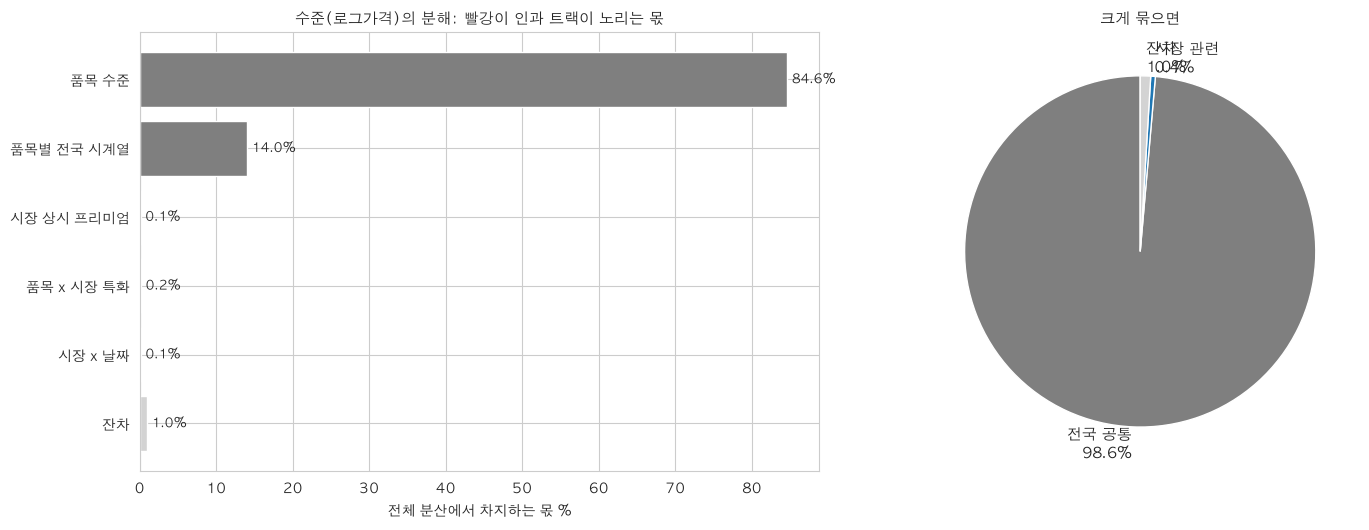

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.4))

ax = axes[0]
s = 수준.drop(index=["— 합계 —", "— 실제 총분산 —"])
cols = ["tab:gray", "tab:gray", "tab:blue", "tab:blue", "tab:red", "lightgray"]
ax.barh(s.index, s["몫 %"], color=cols)
for i, v in enumerate(s["몫 %"]):
    ax.text(v + 0.6, i, f"{v:.1f}%", va="center", fontsize=9.5)
ax.set_xlabel("전체 분산에서 차지하는 몫 %")
ax.set_title("수준(로그가격)의 분해: 빨강이 인과 트랙이 노리는 몫", fontsize=11)
ax.invert_yaxis()

ax = axes[1]
시장계 = s.loc[["시장 상시 프리미엄", "품목 x 시장 특화", "시장 x 날짜"], "몫 %"].sum()
전국계 = s.loc[["품목 수준", "품목별 전국 시계열"], "몫 %"].sum()
ax.pie([전국계, 시장계, s.loc["잔차", "몫 %"]],
       labels=[f"전국 공통\n{전국계:.1f}%", f"시장 관련\n{시장계:.1f}%",
               f"잔차\n{s.loc['잔차','몫 %']:.1f}%"],
       colors=["tab:gray", "tab:blue", "lightgray"],
       startangle=90, textprops={"fontsize": 11})
ax.set_title("크게 묶으면", fontsize=11)

plt.tight_layout()
plt.show()

## 3. 변화의 분해

**여기가 더 중요합니다.** 수준의 시장 몫이 커도 그게 **상수**라면 움직임을
설명하지 못합니다. "가락이 늘 10% 비싸다"는 처치가 될 수 없습니다.

같은 분해를 **전일 대비 로그 변화**에 적용합니다. 여기서 시장 몫이 크면
**시장마다 다르게 움직인다**는 뜻이고, 그때 비로소 처치를 찾을 값어치가
있습니다.

In [4]:
d2 = d.sort_values(["item", "market", "price_date"]).copy()
d2["dlog"] = d2.groupby(["item", "market"]).logp.diff()
d2["간격"] = d2.groupby(["item", "market"]).price_date.diff().dt.days
d2 = d2[(d2.간격 <= 7) & d2.dlog.notna()]        # 7일 넘게 벌어진 건 변화로 안 본다
cnt2 = d2.groupby(["item", "price_date"]).market.transform("nunique")
d2 = d2[cnt2 == len(MAIN)].reset_index(drop=True)
print(f"변화 분해 대상 {len(d2):,}행 (간격 7일 이하, 5시장 모두 관측)")

변화, _ = 분해(d2, "dlog")
display(변화.round(5))
시장몫2 = 변화.loc["시장 x 날짜", "몫 %"]
print(f"\n>>> 변화 기준 시장 x 날짜 몫: {시장몫2:.2f}%")
print(f"    (수준 기준은 {시장몫:.2f}% 였습니다)")

변화 분해 대상 107,650행 (간격 7일 이하, 5시장 모두 관측)


,분산,몫 %
품목 수준,0.00000,0.00707
품목별 전국 시계열,0.00332,48.95976
시장 상시 프리미엄,0.00000,0.00016
품목 x 시장 특화,0.00000,0.00084
시장 x 날짜,0.00034,5.02516
잔차,0.00312,46.00702
— 합계 —,0.00678,100.00000
— 실제 총분산 —,0.00678,100.00000



>>> 변화 기준 시장 x 날짜 몫: 5.03%
    (수준 기준은 0.14% 였습니다)


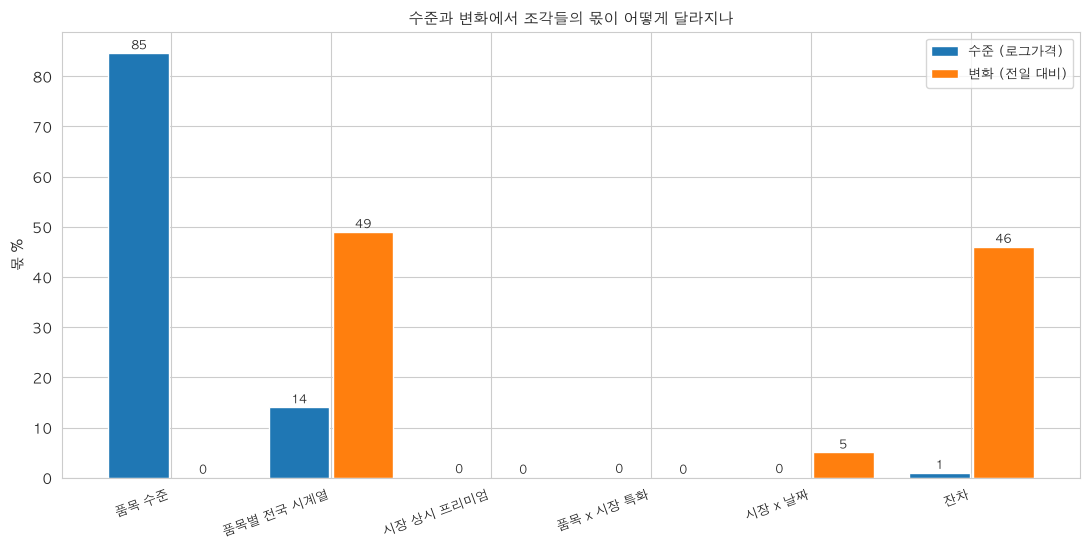

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.6))
a = 수준.drop(index=["— 합계 —", "— 실제 총분산 —"])["몫 %"]
b = 변화.drop(index=["— 합계 —", "— 실제 총분산 —"])["몫 %"]
x = np.arange(len(a))
ax.bar(x - 0.2, a.values, width=0.38, color="tab:blue", label="수준 (로그가격)")
ax.bar(x + 0.2, b.values, width=0.38, color="tab:orange", label="변화 (전일 대비)")
for i, (v1, v2) in enumerate(zip(a.values, b.values)):
    ax.text(i - 0.2, v1 + 0.8, f"{v1:.0f}", ha="center", fontsize=8.5)
    ax.text(i + 0.2, v2 + 0.8, f"{v2:.0f}", ha="center", fontsize=8.5)
ax.set_xticks(x)
ax.set_xticklabels(a.index, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("몫 %")
ax.set_title("수준과 변화에서 조각들의 몫이 어떻게 달라지나", fontsize=11)
ax.legend(fontsize=9.5)
plt.tight_layout()
plt.show()

## 4. 품목마다 다른가

전체 평균 뒤에 편차가 숨어 있을 수 있습니다. 품목별로 따로 분해해
**시장 축이 통하는 품목**이 있는지 봅니다.

**주의: 품목 하나 안에서는 '시장 x 날짜'와 '잔차'를 가를 수 없습니다.**
(시장, 날짜) 조합마다 관측이 하나뿐이라 두 조각이 같은 것이 됩니다. 2절에서
둘을 가를 수 있었던 건 여러 품목을 걸쳐 평균냈기 때문입니다.

그래서 여기서는 **시장 상시**와 **시장 고유 변동**(= 그날 그 시장만, 잔차와
동일) 둘로만 가릅니다.

In [6]:
rows = []
for it, s in d.groupby("item"):
    if s.price_date.nunique() < 200:
        continue
    x = s.copy()
    x["B"] = x.groupby("price_date").logp.transform("mean")
    x["rel"] = x.logp - x.B
    x["m"] = x.groupby("market").rel.transform("mean")
    고유 = x.rel - x.m          # 품목 하나에서는 이게 곧 '그날 그 시장만'
    tot = x.logp.var()
    rows.append({"item": it, "관측일": x.price_date.nunique(),
                 "전국 시계열 %": x.B.var() / tot * 100,
                 "시장 상시 %": x.m.var() / tot * 100,
                 "시장 고유 변동 %": 고유.var() / tot * 100})
품목별 = pd.DataFrame(rows).set_index("item").sort_values("시장 고유 변동 %",
                                                       ascending=False)
품목별["시장 합계 %"] = 품목별["시장 상시 %"] + 품목별["시장 고유 변동 %"]
display(품목별.round(2))
print("'시장 고유 변동' 은 그날 그 시장만의 움직임입니다(품목 하나라 잔차와 같습니다).")
print("2절의 '시장 x 날짜'(0.14%)보다 큰 이유는, 여기엔 시장 공통 충격과")
print("품목x시장x날짜 노이즈가 함께 들어 있기 때문입니다. 상한으로 읽으세요.")

,관측일,전국 시계열 %,시장 상시 %,시장 고유 변동 %,시장 합계 %
item,,,,,
열무,1372,66.88,11.60,21.53,33.12
얼갈이배추,1372,82.21,2.41,15.38,17.79
풋고추,1088,83.48,2.67,13.85,16.52
고구마,1372,87.45,1.64,10.91,12.55
깻잎,1372,86.54,2.77,10.69,13.46
브로콜리,665,85.58,3.86,10.55,14.42
미나리,1272,87.79,2.25,9.95,12.21
알배기배추,776,86.18,5.50,8.32,13.82
파,1370,90.14,1.88,7.98,9.86


'시장 고유 변동' 은 그날 그 시장만의 움직임입니다(품목 하나라 잔차와 같습니다).
2절의 '시장 x 날짜'(0.14%)보다 큰 이유는, 여기엔 시장 공통 충격과
품목x시장x날짜 노이즈가 함께 들어 있기 때문입니다. 상한으로 읽으세요.


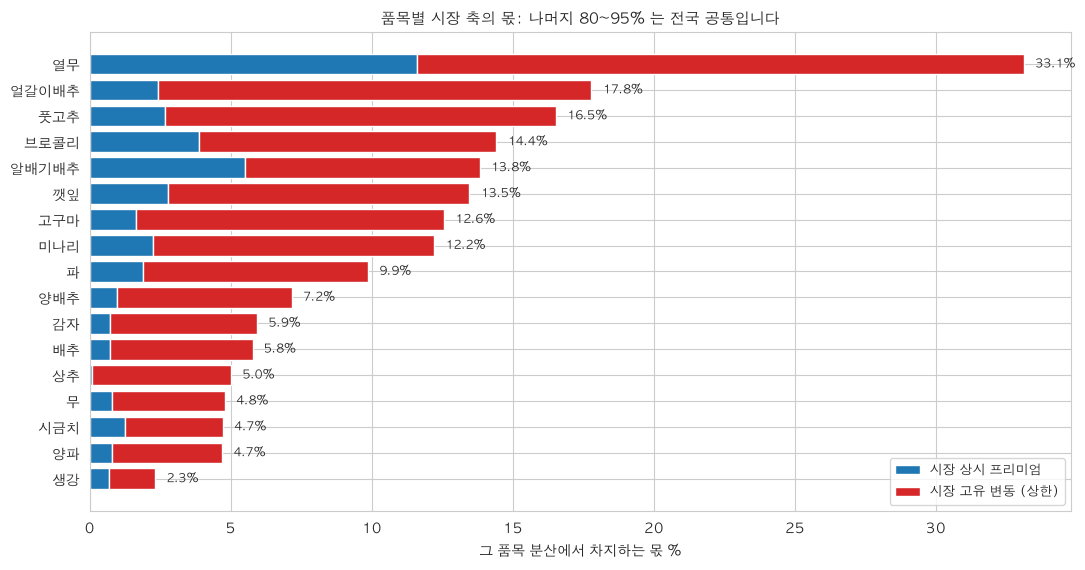

In [7]:
fig, ax = plt.subplots(figsize=(11, 5.8))
p = 품목별.sort_values("시장 합계 %")
ax.barh(p.index, p["시장 상시 %"], color="tab:blue", label="시장 상시 프리미엄")
ax.barh(p.index, p["시장 고유 변동 %"], left=p["시장 상시 %"],
        color="tab:red", label="시장 고유 변동 (상한)")
for i, v in enumerate(p["시장 합계 %"]):
    ax.text(v + 0.4, i, f"{v:.1f}%", va="center", fontsize=8.5)
ax.set_xlabel("그 품목 분산에서 차지하는 몫 %")
ax.set_title("품목별 시장 축의 몫: 나머지 80~95% 는 전국 공통입니다", fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 5. 정리

### 한 줄 요약

**시장 축은 작습니다.** 가격 수준의 **98.6%** 가 전국 공통이고 시장 관련은
**0.4%** 입니다. 변화로 봐도 시장 몫은 **5.03%** 로 미리 정한 합격선의
경계에 걸칩니다. **인과 트랙을 접습니다.**

### 수준의 분해 — 시장은 0.4%

조각들의 합이 실제 총분산과 **정확히 일치**했습니다(0.8827). 직교 분해가
제대로 됐다는 뜻이라 아래 숫자를 그대로 읽어도 됩니다.

| 조각 | 몫 |
|---|---|
| 품목 수준 (배추 vs 마늘) | **84.59%** |
| 품목별 전국 시계열 (계절·작황) | **14.03%** |
| 시장 상시 프리미엄 | 0.12% |
| 품목 × 시장 특화 | 0.16% |
| **시장 × 날짜** | **0.14%** |
| 잔차 | 0.95% |

**전국 공통이 98.6%, 시장 관련이 전부 합쳐 0.42%** 입니다. 22번에서 "시장 간
1.10~1.59배 차이"를 봤을 때 커 보였지만, **품목 간 가격차가 워낙 커서 전체
분산에서는 반올림 오차 수준**입니다.

### 변화의 분해 — 5.03%

| 조각 | 몫 |
|---|---|
| 품목별 전국 시계열 | **48.96%** |
| **시장 × 날짜** | **5.03%** |
| 잔차 | **46.01%** |
| 나머지 조각 | ~0% |

**수준의 0.14% 에서 변화의 5.03% 로 36배 커집니다.** 시장 상시 프리미엄은
상수라 변화에서 사라지고, 남는 게 "그날 그 시장만" 부분이기 때문입니다.

그래도 **5.03% 는 미리 정한 판정에서 "미미" 구간**(5~15%)의 아래쪽 끝입니다.

**잔차가 46% 라는 것도 눈여겨볼 대목입니다.** 일별 가격 변화의 절반이 품목·
시장·날짜 어느 축으로도 설명되지 않습니다. 예측 트랙에서 방향을 62.8% 밖에
못 맞힌 것과 같은 얘기를 다른 각도에서 보여줍니다.

### 품목별로는 엽채류가 큽니다 (다만 상한입니다)

| 품목 | 전국 시계열 | 시장 상시 | 시장 고유 변동 | 시장 합계 |
|---|---|---|---|---|
| **열무** | 66.88% | 11.60% | 21.53% | **33.12%** |
| 얼갈이배추 | 82.21% | 2.41% | 15.38% | 17.79% |
| 풋고추 | 83.48% | 2.67% | 13.85% | 16.52% |
| 브로콜리 | 85.58% | 3.86% | 10.55% | 14.42% |
| … | | | | |
| 무 | 95.20% | 0.80% | 3.99% | 4.80% |
| 생강 | 97.68% | 0.67% | 1.65% | **2.32%** |

**⚠️ '시장 고유 변동' 은 상한입니다.** 품목 하나 안에서는 (시장, 날짜) 조합에
관측이 하나뿐이라 **시장 공통 충격과 품목×시장×날짜 노이즈를 가를 수
없습니다.** 2절에서 둘을 가를 수 있었던 건 여러 품목을 걸쳐 평균냈기
때문이고, 거기서는 0.14% 였습니다. **실제 시장 효과는 이 표의 값보다 훨씬
작습니다.**

**열무·얼갈이배추·풋고추가 위에 오는 건 22번과 같은 패턴**입니다: 저장이 안
되는 엽채류일수록 시장 간 차이가 큽니다. 재고로 평준화가 안 되기 때문으로
읽히지만, 이건 관찰이지 증명이 아닙니다.

### 판정: 인과 트랙을 접습니다

미리 정한 기준에 따릅니다.

| 기준 | 결과 |
|---|---|
| 5% 미만이면 축이 무의미 | 수준 **0.14%** → 해당 |
| 5~15% 면 외부 데이터 없이는 어려움 | 변화 **5.03%** → 경계선 |

**처치를 더 찾을 이유가 없습니다.** 23번에서 후보가 안 나온 게 우연이 아니라,
**애초에 시장 고유 변동 자체가 작아서** 사건이 있어도 잡히지 않는 것입니다.
23번의 명절 사건 2개가 전부였던 것과 맞물립니다.

### 이 트랙에서 남는 것

접더라도 얻은 게 있습니다.

- **그레인 규칙**: `variety` 가 아니라 `kindname_raw`(22번). 원천을 다시 쓸 때
  반드시 지켜야 합니다.
- **마트 설계가 옳았습니다**: 마트가 시장 축을 접어 '날짜 × 품목'으로 만든 게
  정보 손실이 아니었습니다. 버린 축이 전체의 0.4% 였습니다.
- **엽채류는 시장 차이가 상대적으로 큽니다**: 열무 33%(상한). 지역 유통을
  다루는 다른 질문에는 쓸 수 있습니다.

### 한계

- **5개 시장뿐**입니다. 전국 도매시장은 훨씬 많고, 여기 없는 시장 간에는
  차이가 더 클 수 있습니다.
- **미거래 32.5% 를 뺐습니다.** 거래가 성사된 날만 남긴 값이라, 시장 간
  차이가 큰 날이 체계적으로 빠졌을 수 있습니다.
- **가격만 봤습니다.** 물량(반입량)은 시장별로 훨씬 다를 수 있고, 그건 이
  데이터에 없습니다.

### 다음

**통계·인과 트랙을 닫고 예측 트랙의 남은 항목으로 돌아갑니다.** 남은 것은
전부 모델 밖 정보입니다: 보관비 실측치, 등급 하락·감모, 신규 13품목 출하량
매핑(21번에서 근거가 되살아남).